In [4]:
import sys
import os

# 1. See the exact paths Python is searching for your modules
print("--- Python Import Paths ---")
for path in sys.path:
    print(path)

--- Python Import Paths ---
/home/theppawan/miniconda3/envs/ml_env/lib/python314.zip
/home/theppawan/miniconda3/envs/ml_env/lib/python3.14
/home/theppawan/miniconda3/envs/ml_env/lib/python3.14/lib-dynload

/home/theppawan/miniconda3/envs/ml_env/lib/python3.14/site-packages
/home/theppawan/nn-models/source


In [5]:
# Setup
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from utils.data_reader import load_and_prepare_time_series_data
from utils.trainer import Trainer
from models.baseline_models import LSTMModel

In [6]:
data_url = "https://storage.googleapis.com/covid19-open-data/v3/location/US.csv"

# Safely unpack the data reader results regardless of which version you have
results = load_and_prepare_time_series_data(
    filepath_or_url=data_url,
    target_column="new_confirmed",
    date_column="date",
    seq_length=14,
    batch_size=32,
    train_split=0.8,
    fill_missing=True
)

train_loader, val_loader, val_dataset, scaler = results

Fetching data from: https://storage.googleapis.com/covid19-open-data/v3/location/US.csv
Sorting data chronologicall by column: date
Succesfully loaded 991 sequential data points.
Prepared Training batches: 25 | Validation batches: 6


In [7]:
model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, output_size=1)   
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [8]:
trainer = Trainer(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        device="cpu"
    )
trainer.train(train_loader=train_loader, val_loader=val_loader, epochs=1000)

Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Training complete!


([0.012866320008301874,
  0.008799726398455837,
  0.004469897385098873,
  0.003596220099726922,
  0.003499698584045195,
  0.0031010455524927163,
  0.0030689853848650055,
  0.0031787775931843964,
  0.0033902933133962373,
  0.002885582622357316,
  0.0031253181201594963,
  0.002884554642969072,
  0.002787842742822212,
  0.0028295633869406056,
  0.0026947621724168484,
  0.0026553665456280667,
  0.002715467315358421,
  0.0025379351989047692,
  0.0026095023490282036,
  0.0024980550648452736,
  0.0025683864045099314,
  0.0024947998506570077,
  0.002587925063270793,
  0.0027410977328217716,
  0.0026977099416146634,
  0.0024085925259941035,
  0.0024453471700545963,
  0.002502723370743365,
  0.00294428576229279,
  0.002656254208716145,
  0.002788236423378815,
  0.0024183593035147677,
  0.0024594184457729057,
  0.002606064121892489,
  0.002340116924462615,
  0.0023405301506729237,
  0.00313980541321279,
  0.002337688388735963,
  0.0022928282444348563,
  0.0024247769802655536,
  0.0023881967292002

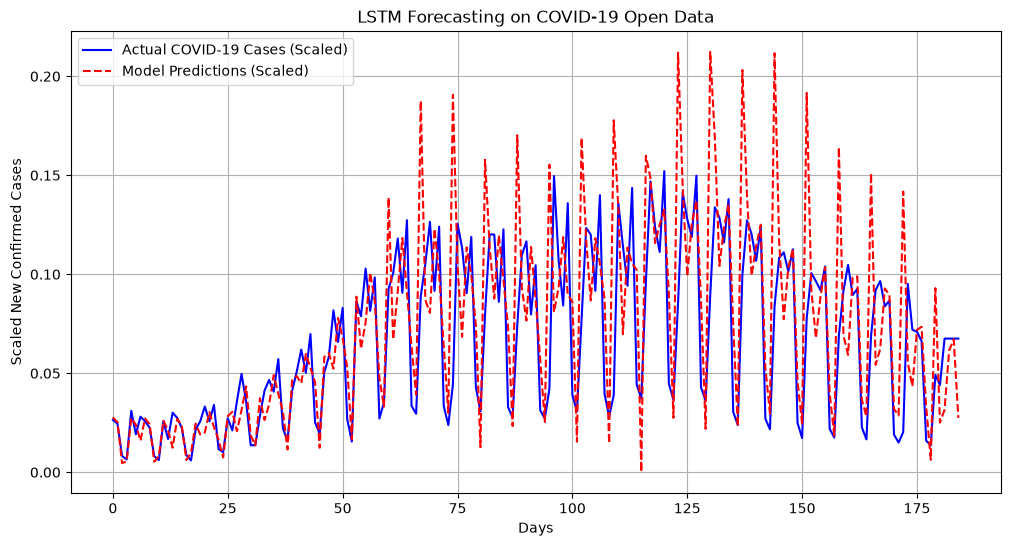

In [9]:
model.eval()
    
actuals = []
predictions = []

with torch.no_grad():
    for batch_x, batch_y in val_loader:
        batch_x = batch_x.to(trainer.device)
        preds = model(batch_x)
        
        actuals.extend(batch_y.cpu().numpy().flatten())
        predictions.extend(preds.cpu().numpy().flatten())
        
# Plotting the validation data
plt.figure(figsize=(12, 6))
plt.plot(actuals, label="Actual COVID-19 Cases (Scaled)", color="blue")
plt.plot(predictions, label="Model Predictions (Scaled)", color="red", linestyle="--")
plt.title("LSTM Forecasting on COVID-19 Open Data")
plt.xlabel("Days")
plt.ylabel("Scaled New Confirmed Cases")
plt.legend()
plt.grid(True)
plt.show()